# Nama: Roni Gunawan Muhammad
# NIM: 4222311024   
# Kelas: Robotika A Malam

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [3]:
df = pd.read_csv('berat_tinggi.csv')
print(df.head())

       tinggi      berat deskripsi
0  158.114332  58.364240    Normal
1  160.344026  52.560155    Normal
2  161.486080  61.934852    Normal
3  182.459297  69.042108      Slim
4  184.462584  71.341076      Slim


## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

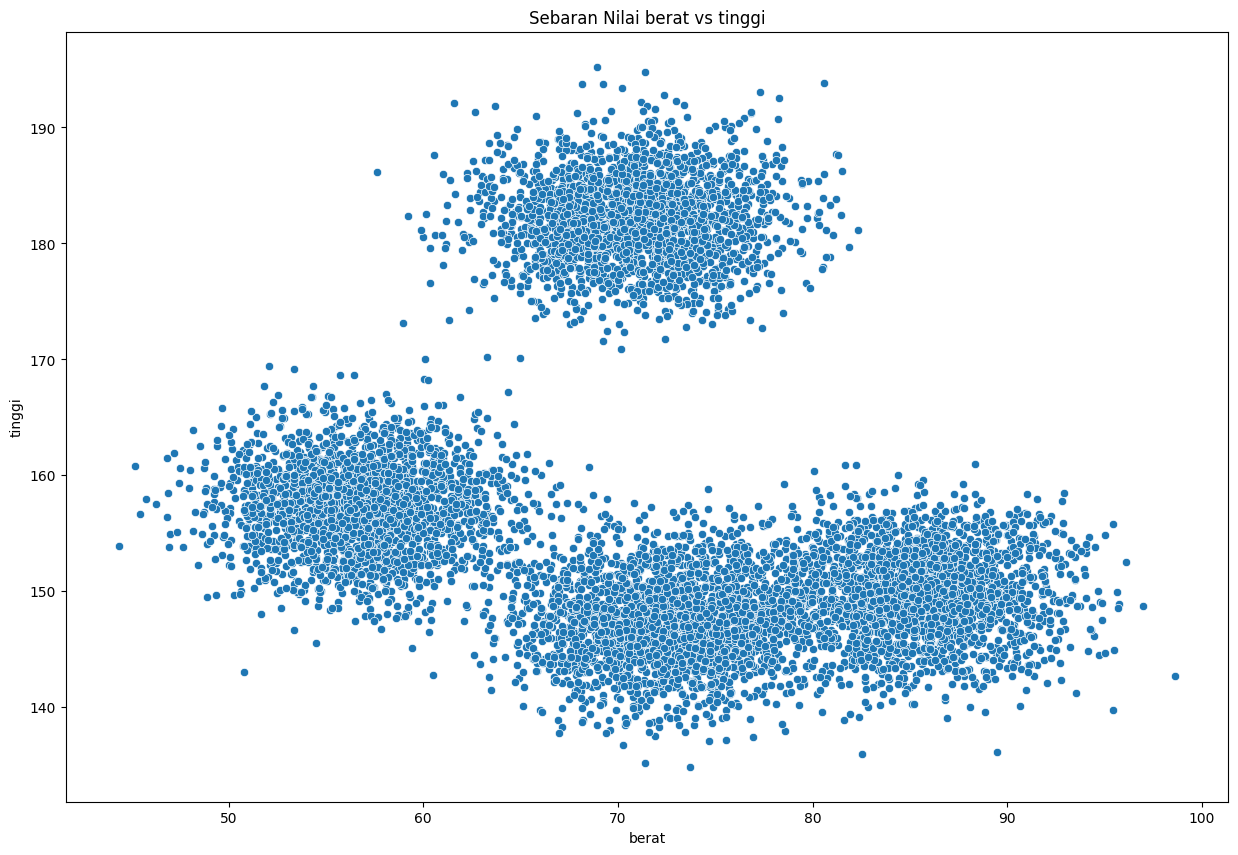

In [4]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [5]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


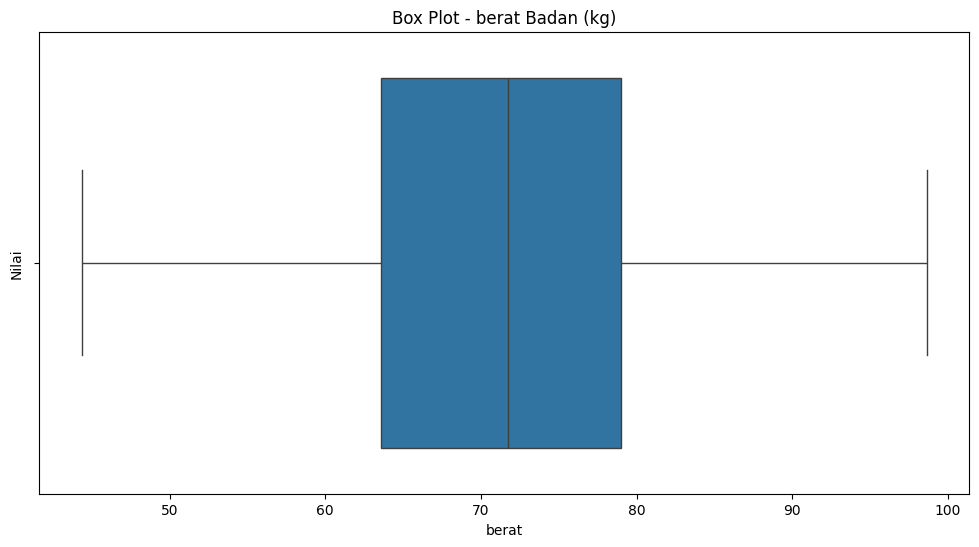

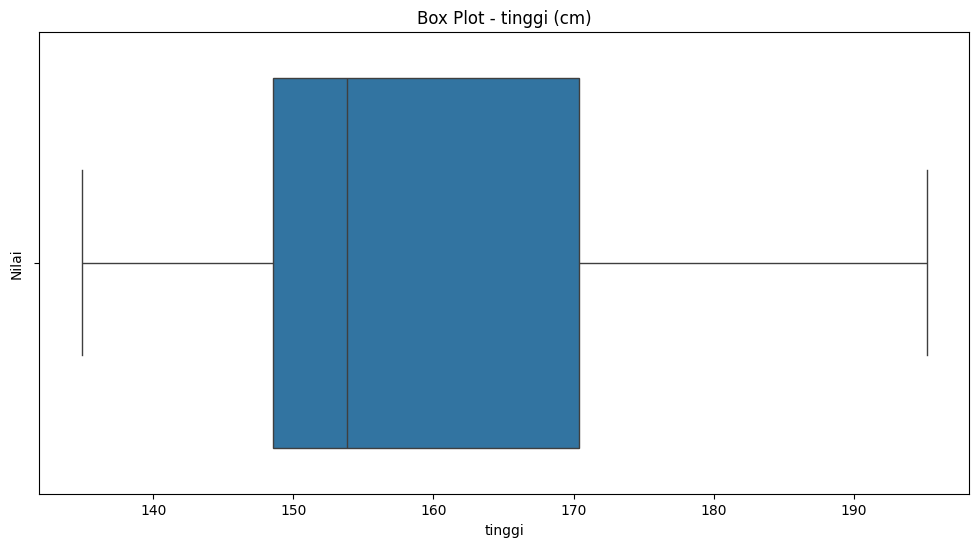

In [6]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

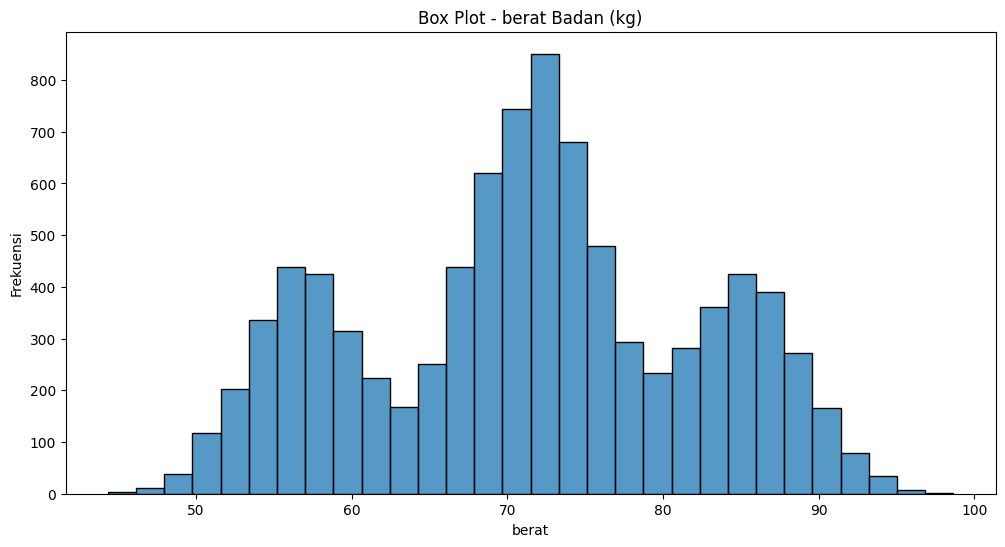

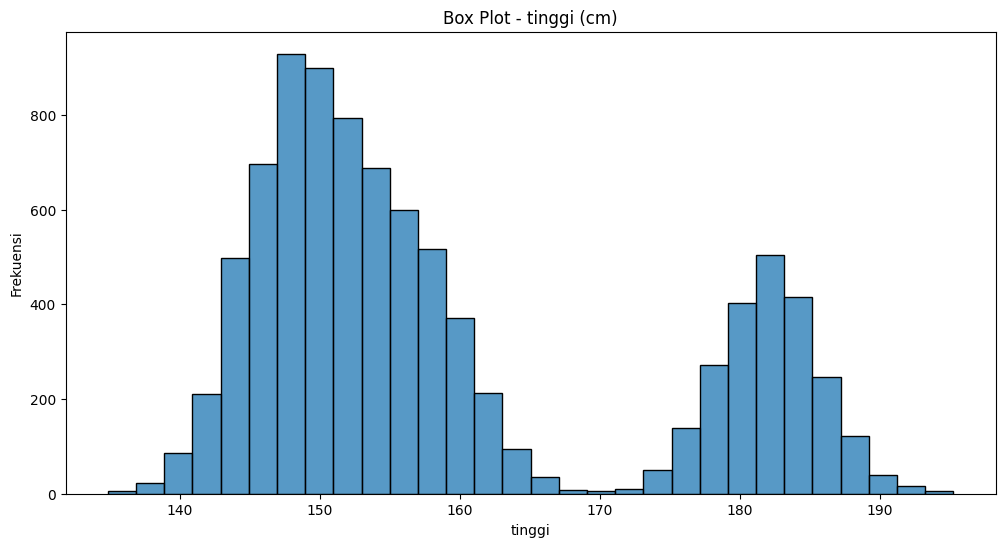

In [7]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [8]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [18]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [21]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


In [15]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]], shape=(8888, 2))

In [16]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

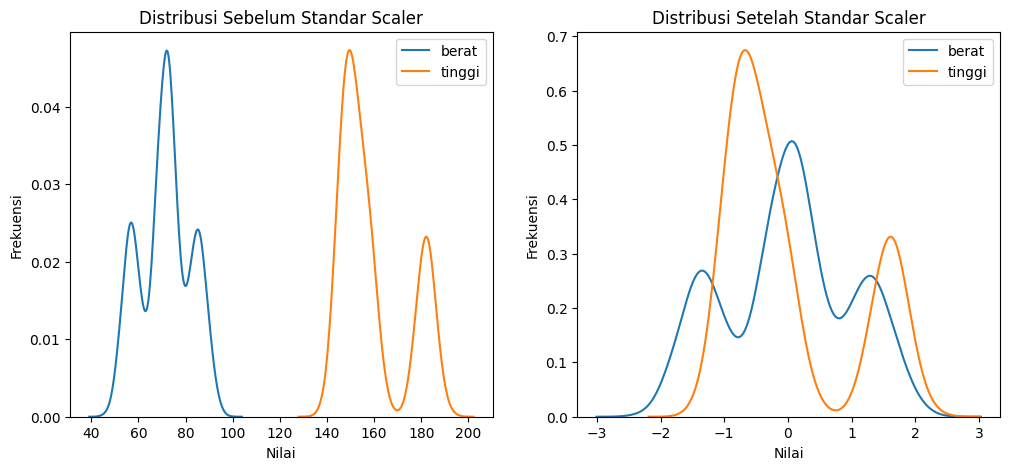

In [28]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
sns.kdeplot(df['berat'], ax=ax1, label='berat')
sns.kdeplot(df['tinggi'], ax=ax1, label='tinggi')
ax1.set_title('Distribusi Sebelum Standar Scaler')
ax1.set_xlabel('Nilai')
ax1.set_ylabel('Frekuensi')

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
sns.kdeplot(df_scalling['berat'], ax=ax2, label='berat')
sns.kdeplot(df_scalling['tinggi'], ax=ax2, label='tinggi')
ax2.set_title('Distribusi Setelah Standar Scaler')
ax2.set_xlabel('Nilai')
ax2.set_ylabel('Frekuensi')

# Set x-labels
ax1.set_xlabel('Nilai')
ax2.set_xlabel('Nilai')

# Menampilkan legenda
ax1.legend(['berat', 'tinggi'])
ax2.legend(['berat', 'tinggi'])

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Setelah StandardScaler, `berat` dan `tinggi` punya skala sama (mean≈0, var≈1).
2. Sebelum scaling, perbedaan skala bisa memengaruhi hasil clustering.
3. Scaling membuat K‑Means lebih adil terhadap kedua fitur; bila masih ada outlier, pakai RobustScaler.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

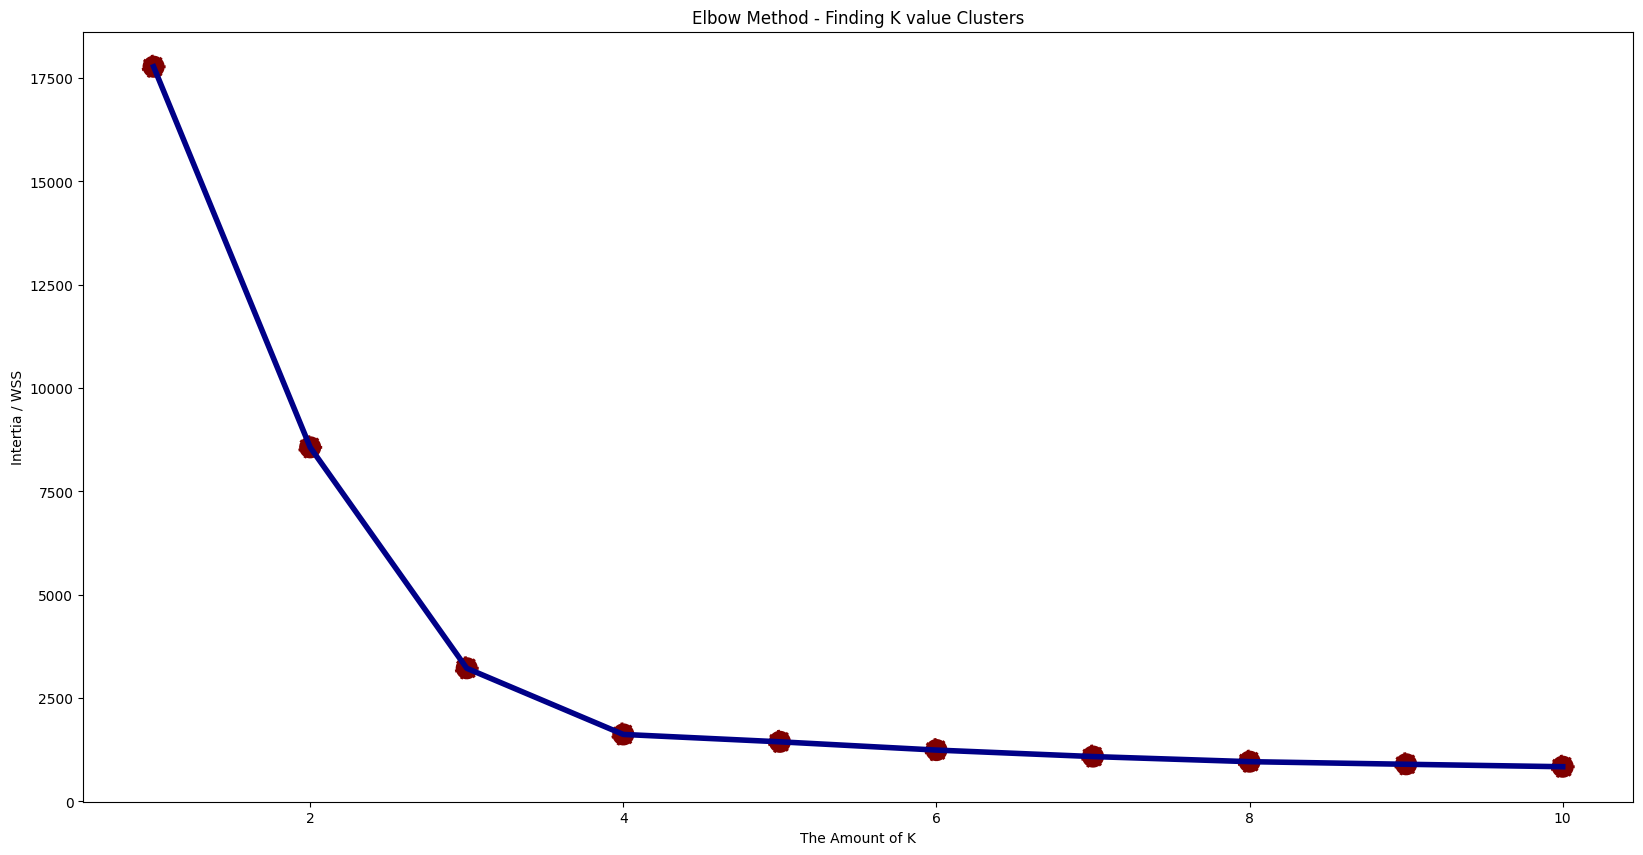

In [29]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [37]:
#Dari hasil diatas elbow nya dipilih pada angka 3,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [38]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [39]:
df

,tinggi,berat,deskripsi,cluster_elbow
0,158.114332,58.364240,Normal,0
1,160.344026,52.560155,Normal,0
2,161.486080,61.934852,Normal,0
3,182.459297,69.042108,Slim,2
4,184.462584,71.341076,Slim,2
...,...,...,...,...
8883,177.296550,74.905033,Slim,2
8884,151.605026,81.084183,Obese,1
8885,158.838120,61.779766,Normal,0
8886,156.592981,54.047666,Normal,0


<Axes: xlabel='berat', ylabel='tinggi'>

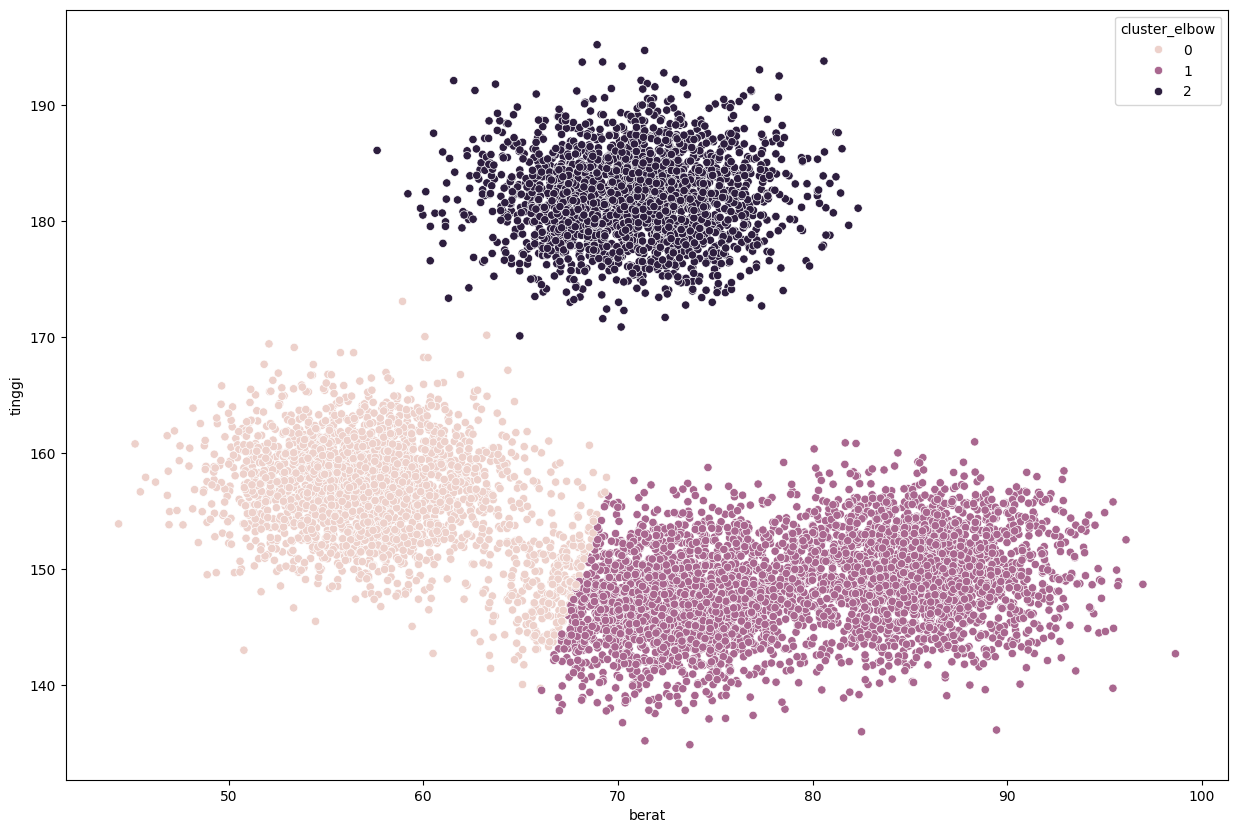

In [40]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

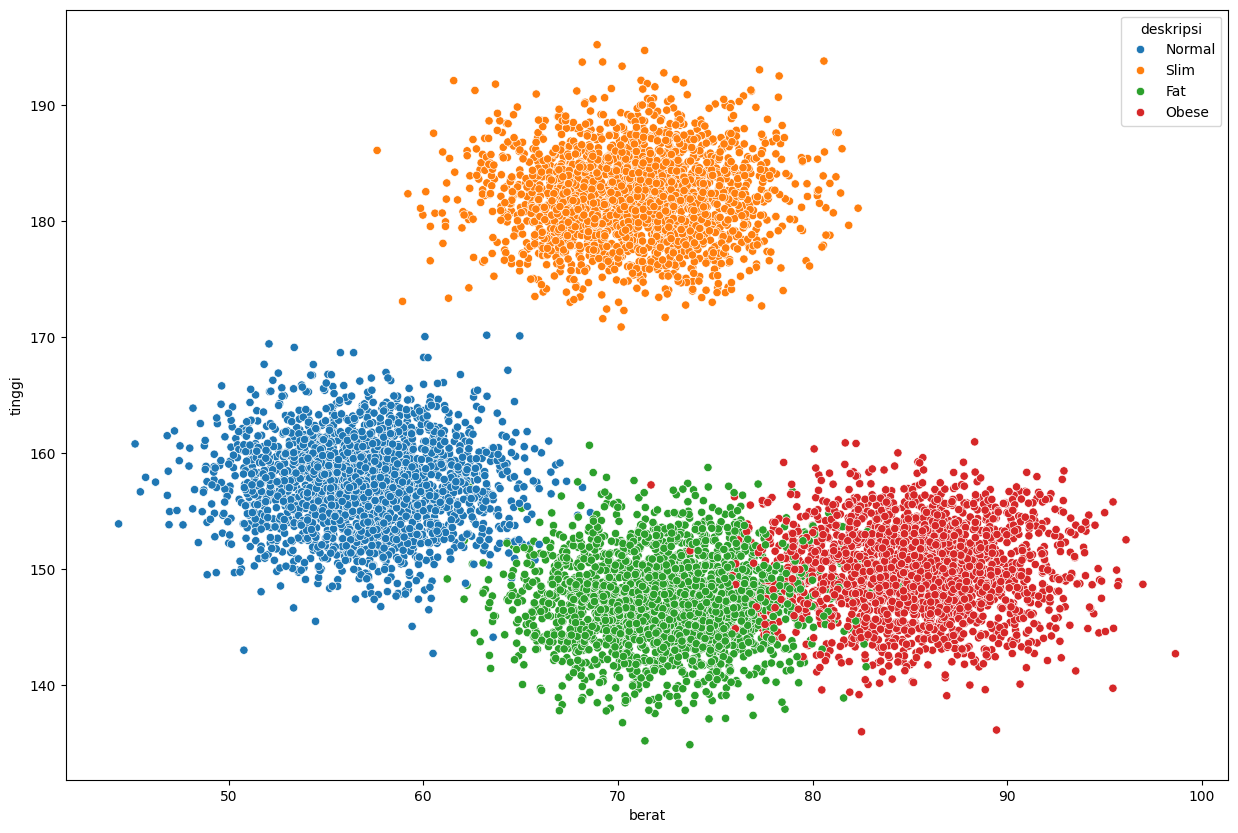

In [41]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [35]:
!pip install yellowbrick


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


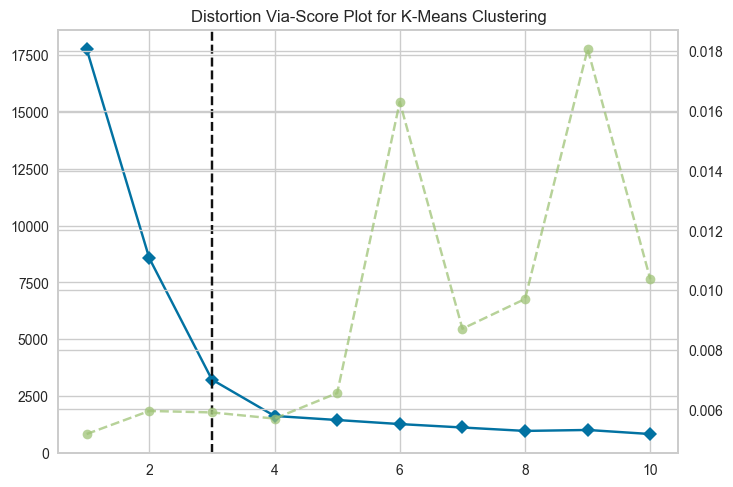

In [42]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [43]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [44]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [45]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,0,0
1,160.344026,52.560155,Normal,0,0
2,161.486080,61.934852,Normal,0,0
3,182.459297,69.042108,Slim,2,2
4,184.462584,71.341076,Slim,2,2
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,2,2
8884,151.605026,81.084183,Obese,1,1
8885,158.838120,61.779766,Normal,0,0
8886,156.592981,54.047666,Normal,0,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='berat', ylabel='tinggi'>

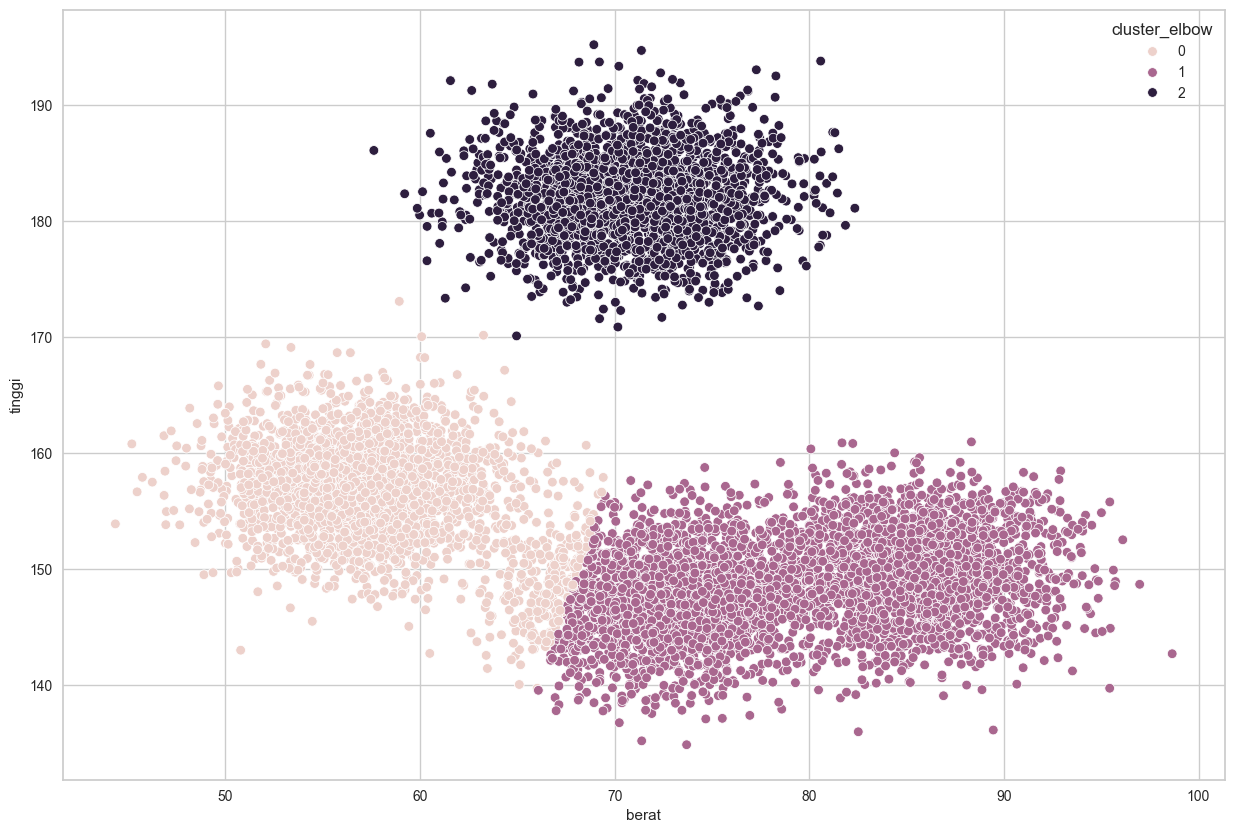

In [47]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')


### Bandingkan dengan label anotator

Adjusted Rand Index (cluster_via vs deskripsi): 0.682


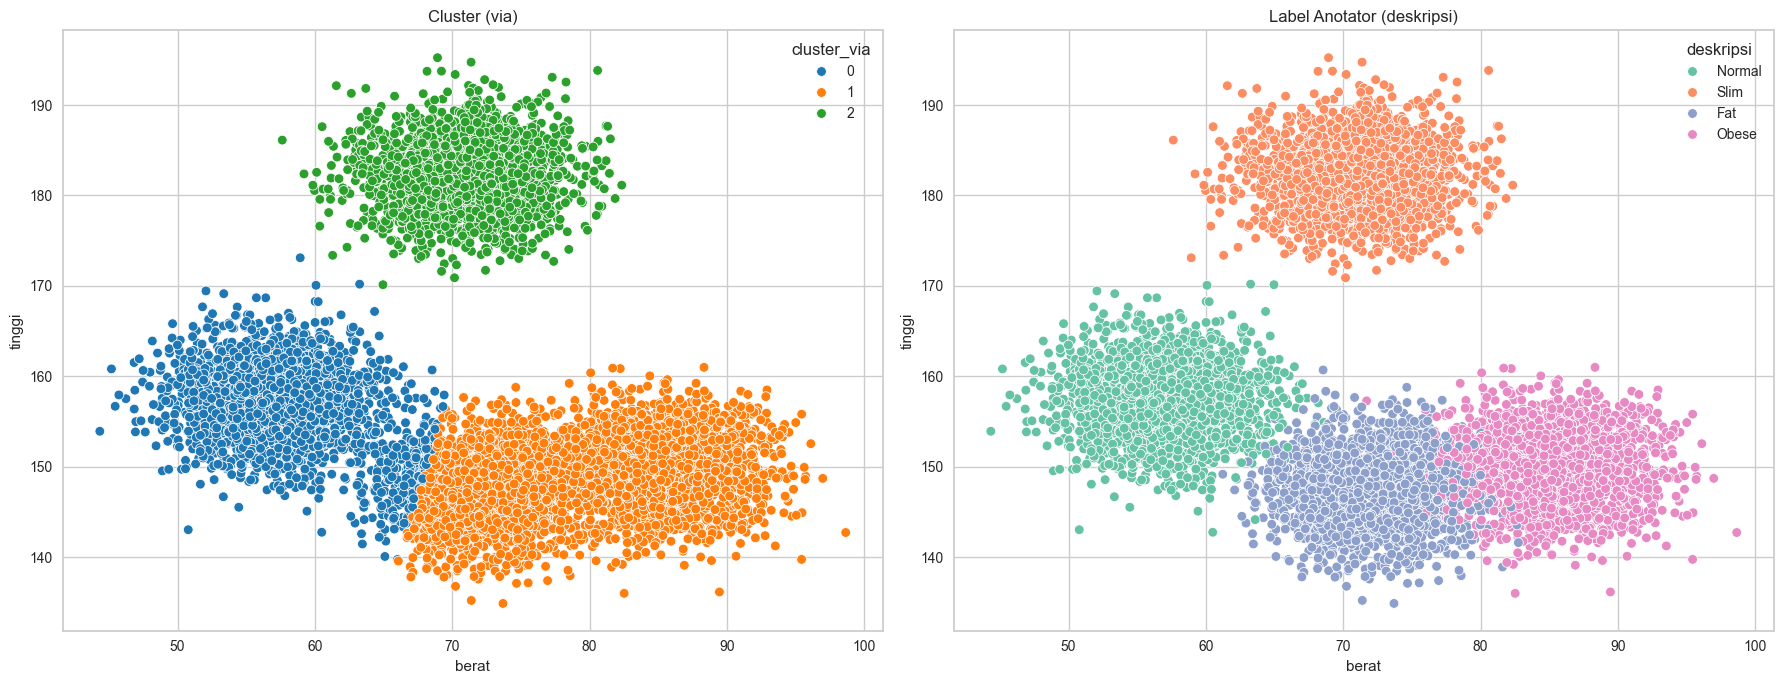

In [55]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['deskripsi'].astype('category').cat.codes, df['cluster_via'])
print('Adjusted Rand Index (cluster_via vs deskripsi):', round(ari, 3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_via', palette='tab10', ax=ax1)
ax1.set_title('Cluster (via)')
sns.scatterplot(data=df, x='berat', y='tinggi', hue='deskripsi', palette='Set2', ax=ax2)
ax2.set_title('Label Anotator (deskripsi)')
plt.tight_layout()
plt.show()

ct = pd.crosstab(df['cluster_via'], df['deskripsi'])




### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Cluster K‑Means (via) umumnya cocok dengan label anotator — pola cluster terlihat mirip distribusi label.
2. Ada perbedaan kecil pada titik outlier atau area tumpang tindih; untuk perbaikan bisa lakukan pra‑proses outlier atau coba scaler alternatif.

### Thank you :)